# SoFit AI — 합성 데이터 EDA

생성된 `s_input_feature_40k.csv` 데이터의 분포와 변수 간 관계를 시각화합니다.

**실행 전 확인사항**
- 가상환경 활성화: `source .venv/bin/activate`
- 패키지 설치: `pip install -r research/requirements.txt`
- 데이터 생성: `python data/generate_data.py`

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import numpy as np

# 한글 폰트 설정 (macOS)
plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False

# 데이터 로드 (노트북 위치 기준 상대 경로)
df = pd.read_csv('../../data/s_input_feature_40k.csv')

GRADE_ORDER = [f'S{i}' for i in range(1, 11)]
print(f'데이터 shape: {df.shape}')
df.head(3)

데이터 shape: (40000, 36)


,feature_id,biz_data_id,user_id,business_age_months,quarterly_revenue_growth_rate,annual_revenue_growth_rate,revenue_vs_industry_avg_ratio,avg_monthly_transaction_3m,avg_monthly_transaction_6m,avg_monthly_transaction_12m,...,review_count,delivery_rating,delivery_order_count,positive_review_ratio,has_online_reservation,owner_experience_years,employee_count,has_sns,created_at,target_s_grade
0,1,46408,15563,51,18.60,34.21,1.11,19669924.73,20363960.47,19897028.77,...,134,4.2,724,95.21,True,1,4,True,2025-09-20 11:05:00,S4
1,2,22657,8542,27,6.91,26.81,1.35,44994213.52,40627989.60,38997368.83,...,336,2.7,564,70.54,False,6,4,False,2025-12-21 13:51:00,S5
2,3,31740,382,21,9.33,19.24,1.41,35455823.29,36195725.03,40445716.39,...,73,3.9,997,85.62,True,12,2,True,2025-12-16 12:48:00,S5


## 1. S등급 분포 — 가우시안 분포 확인

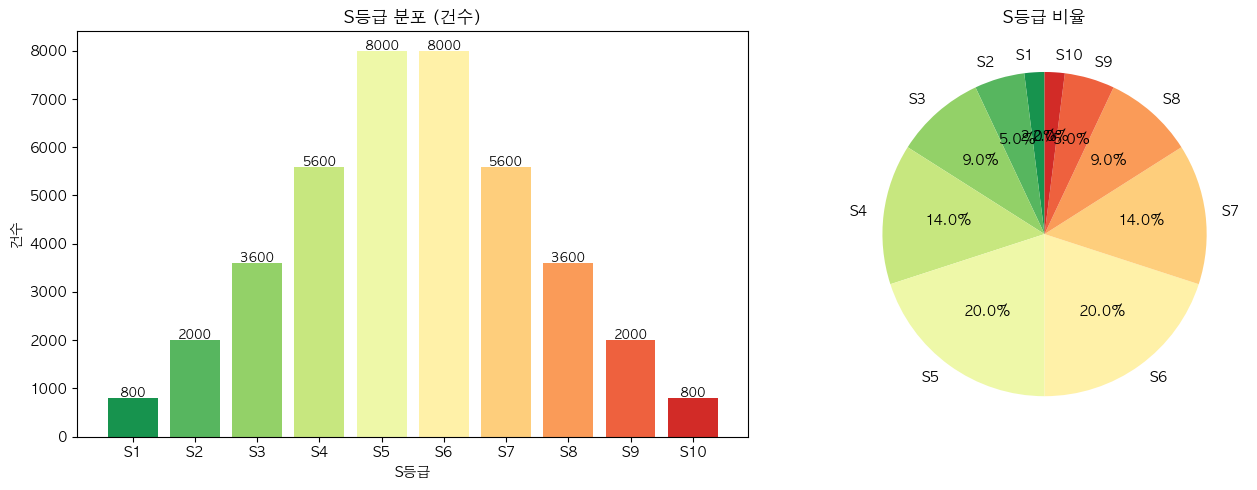

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 막대 그래프
counts = df['target_s_grade'].value_counts().reindex(GRADE_ORDER)
colors = sns.color_palette('RdYlGn_r', 10)
axes[0].bar(GRADE_ORDER, counts.values, color=colors)
axes[0].set_title('S등급 분포 (건수)')
axes[0].set_xlabel('S등급')
axes[0].set_ylabel('건수')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 20, str(v), ha='center', fontsize=9)

# 비율 파이 차트
axes[1].pie(counts.values, labels=GRADE_ORDER, colors=colors,
            autopct='%1.1f%%', startangle=90)
axes[1].set_title('S등급 비율')

plt.tight_layout()
plt.show()

## 2. 등급별 주요 계량 변수 분포 (박스플롯)

S1(최우수)에서 S10(최하위)으로 갈수록 각 변수가 어떻게 변하는지 확인합니다.

/var/folders/69/y4x4v2611vsfb65myl81_kpm0000gn/T/ipykernel_35494/802588806.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='target_s_grade', y=col,
/var/folders/69/y4x4v2611vsfb65myl81_kpm0000gn/T/ipykernel_35494/802588806.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='target_s_grade', y=col,
/var/folders/69/y4x4v2611vsfb65myl81_kpm0000gn/T/ipykernel_35494/802588806.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='target_s_grade', y=col,
/var/folders/69/y4x4v2611vsfb65myl81_kpm0000gn/T/ipyker

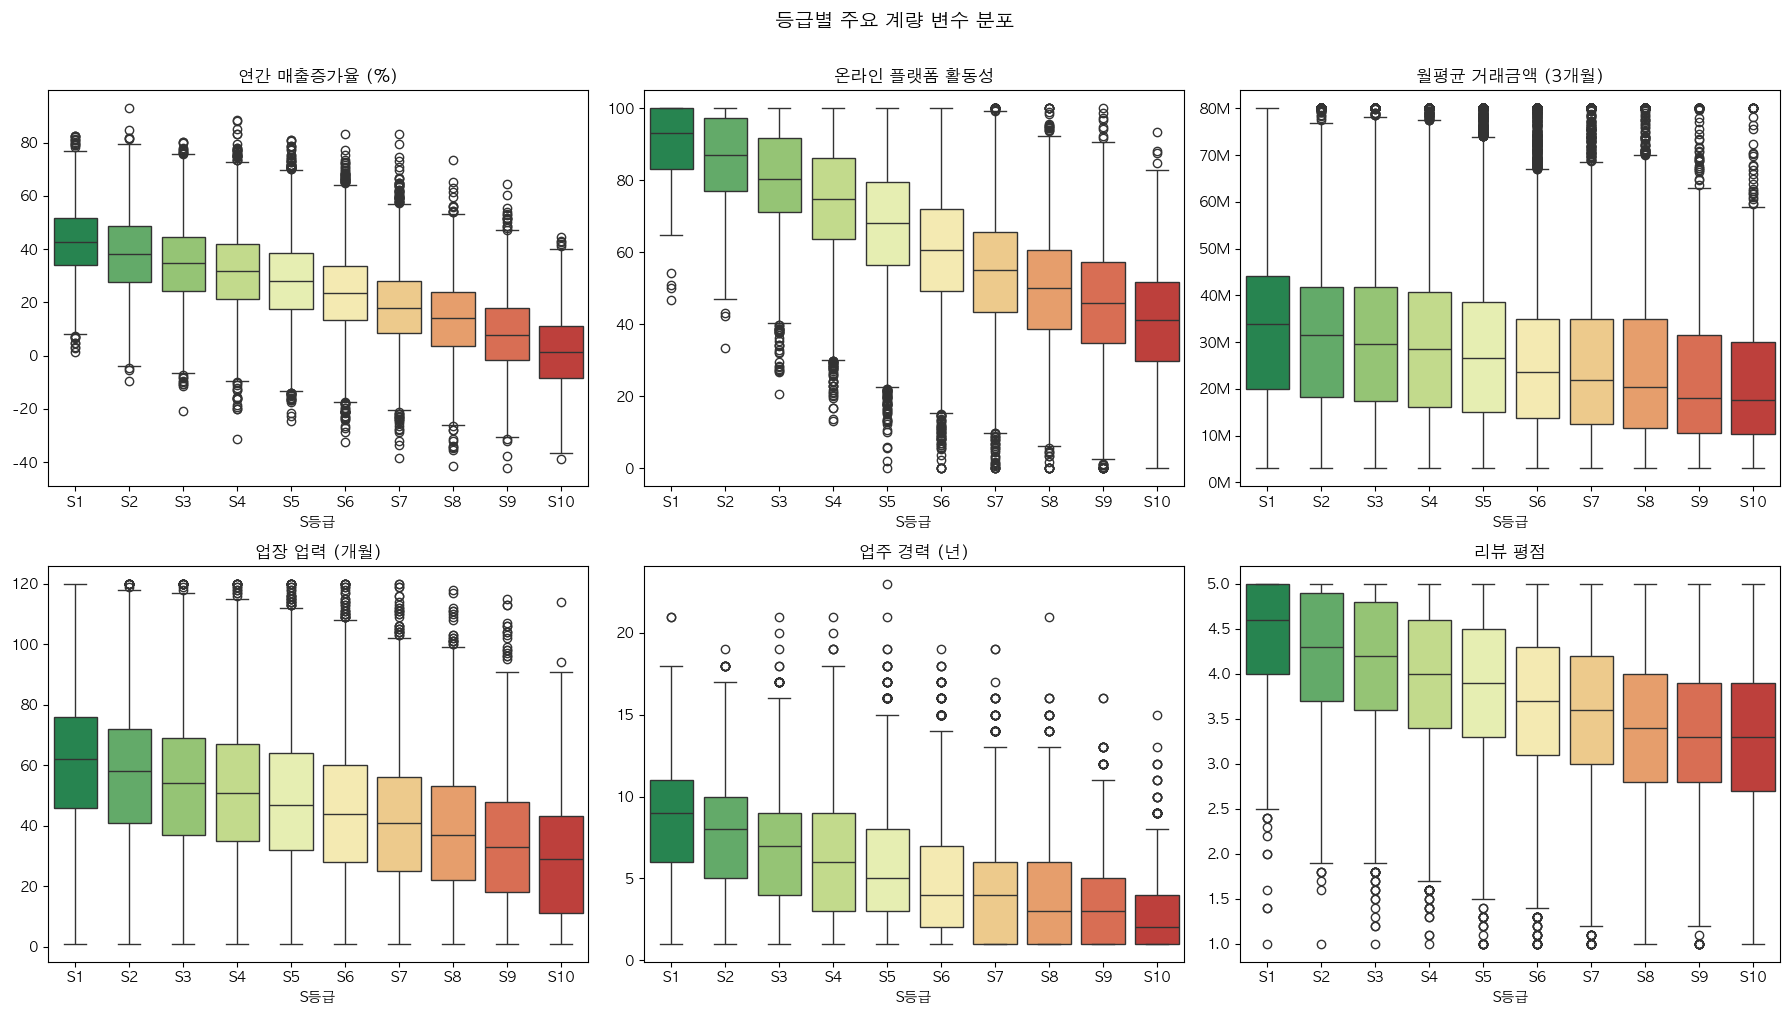

In [3]:
quant_cols = [
    ('annual_revenue_growth_rate', '연간 매출증가율 (%)'),
    ('online_platform_activity_index', '온라인 플랫폼 활동성'),
    ('avg_monthly_transaction_3m', '월평균 거래금액 (3개월)'),
    ('business_age_months', '업장 업력 (개월)'),
    ('owner_experience_years', '업주 경력 (년)'),
    ('review_rating', '리뷰 평점'),
]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for ax, (col, label) in zip(axes.flatten(), quant_cols):
    sns.boxplot(data=df, x='target_s_grade', y=col,
                order=GRADE_ORDER, palette='RdYlGn_r', ax=ax)
    ax.set_title(label, fontsize=12)
    ax.set_xlabel('S등급')
    ax.set_ylabel('')
    if col == 'avg_monthly_transaction_3m':
        ax.yaxis.set_major_formatter(mticker.FuncFormatter(
            lambda x, _: f'{x/1e6:.0f}M'))

plt.suptitle('등급별 주요 계량 변수 분포', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## 3. 등급별 비계량 변수 분포

업주 경력 마일스톤(5년/10년), 역세권, SNS 운영 여부 등 비계량 변수의 등급별 비율을 확인합니다.

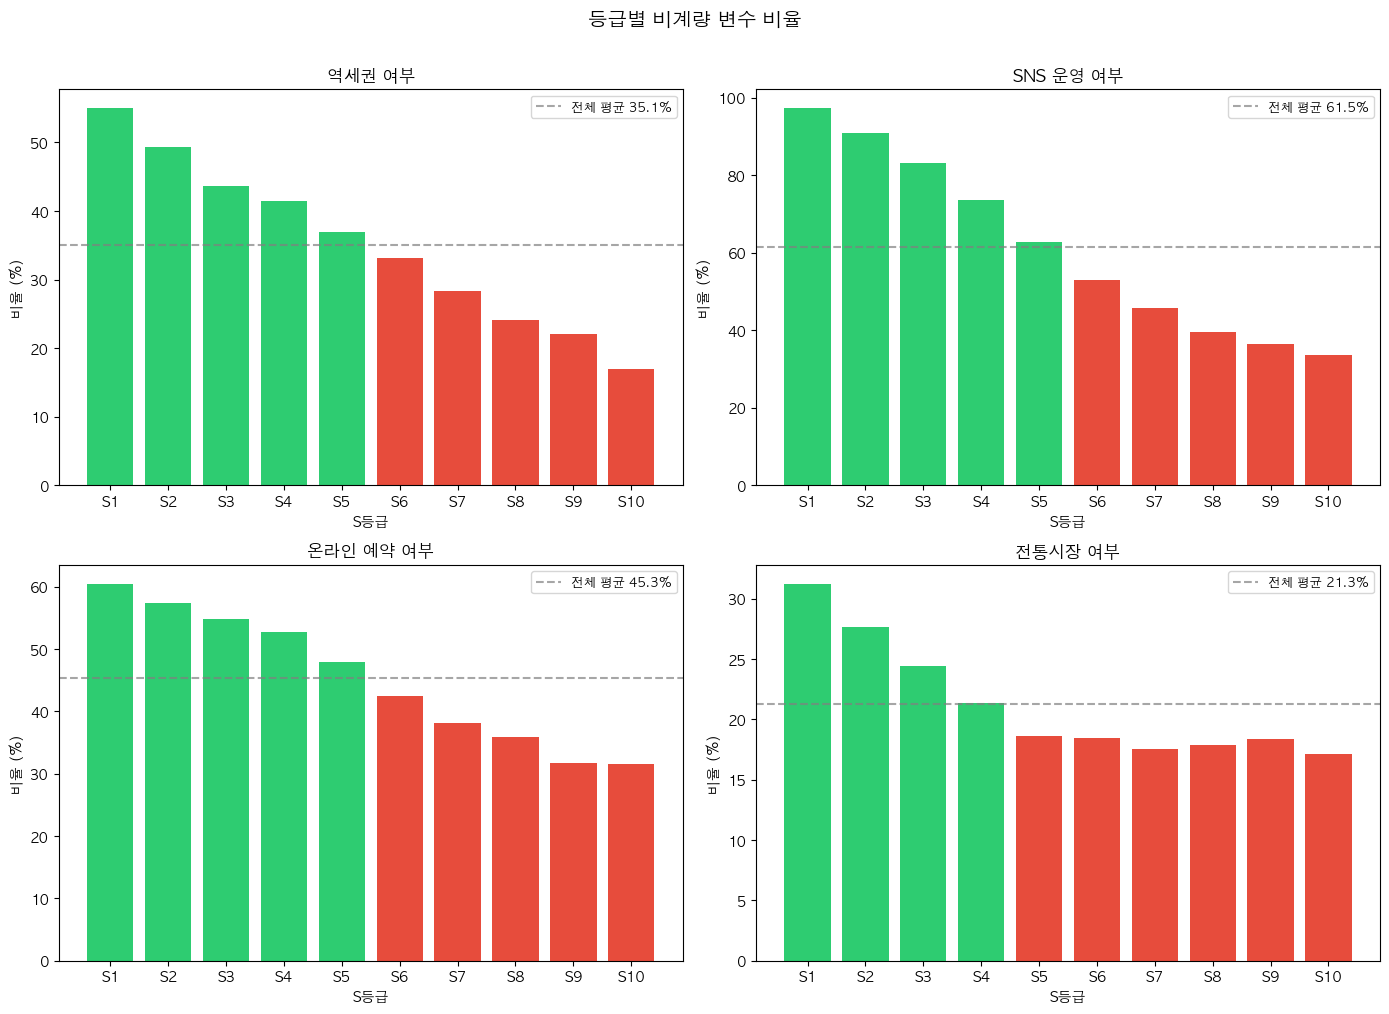

In [4]:
bool_cols = [
    ('is_near_subway', '역세권 여부'),
    ('has_sns', 'SNS 운영 여부'),
    ('has_online_reservation', '온라인 예약 여부'),
    ('is_traditional_market', '전통시장 여부'),
]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, (col, label) in zip(axes.flatten(), bool_cols):
    ratio = df.groupby('target_s_grade')[col].mean().reindex(GRADE_ORDER) * 100
    colors = ['#2ecc71' if v else '#e74c3c'
              for v in (ratio.values > ratio.mean())]
    ax.bar(GRADE_ORDER, ratio.values, color=colors)
    ax.axhline(ratio.mean(), color='gray', linestyle='--', alpha=0.7,
               label=f'전체 평균 {ratio.mean():.1f}%')
    ax.set_title(label, fontsize=12)
    ax.set_xlabel('S등급')
    ax.set_ylabel('비율 (%)')
    ax.legend(fontsize=9)

plt.suptitle('등급별 비계량 변수 비율', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## 4. 업력 마일스톤 효과 확인

업장 업력 5년/10년, 업주 경력 5년/10년 마일스톤이 등급에 미치는 영향을 확인합니다.

/var/folders/69/y4x4v2611vsfb65myl81_kpm0000gn/T/ipykernel_35494/169017978.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  biz_pivot = df.groupby(['biz_age_group', 'target_s_grade']).size().unstack(
/var/folders/69/y4x4v2611vsfb65myl81_kpm0000gn/T/ipykernel_35494/169017978.py:26: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  owner_pivot = df.groupby(['owner_exp_group', 'target_s_grade']).size().unstack(


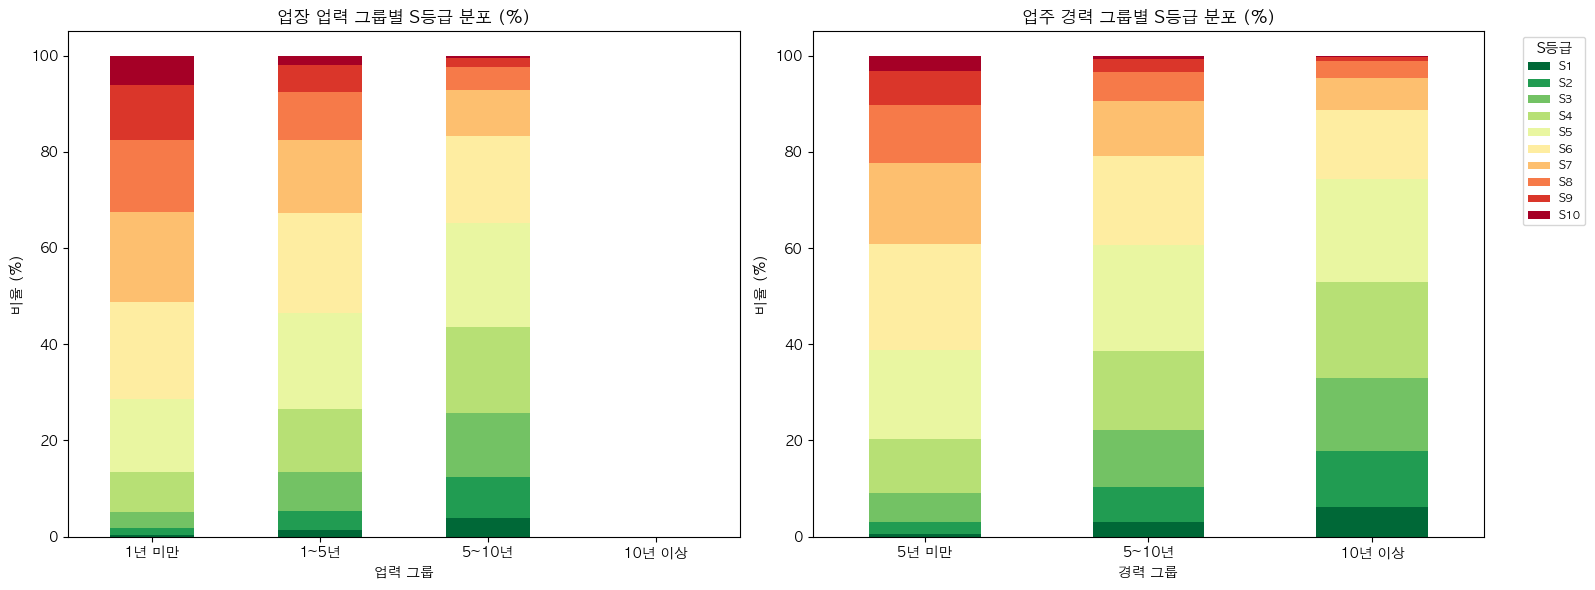

In [5]:
df['biz_age_group'] = pd.cut(
    df['business_age_months'],
    bins=[0, 12, 60, 120, 999],
    labels=['1년 미만', '1~5년', '5~10년', '10년 이상']
)
df['owner_exp_group'] = pd.cut(
    df['owner_experience_years'],
    bins=[0, 5, 10, 999],
    labels=['5년 미만', '5~10년', '10년 이상']
)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 업장 업력 그룹별 등급 분포
biz_pivot = df.groupby(['biz_age_group', 'target_s_grade']).size().unstack(
    fill_value=0).reindex(columns=GRADE_ORDER)
biz_pivot_pct = biz_pivot.div(biz_pivot.sum(axis=1), axis=0) * 100
biz_pivot_pct.plot(kind='bar', stacked=True, ax=axes[0],
                   colormap='RdYlGn_r', legend=False)
axes[0].set_title('업장 업력 그룹별 S등급 분포 (%)')
axes[0].set_xlabel('업력 그룹')
axes[0].set_ylabel('비율 (%)')
axes[0].tick_params(axis='x', rotation=0)

# 업주 경력 그룹별 등급 분포
owner_pivot = df.groupby(['owner_exp_group', 'target_s_grade']).size().unstack(
    fill_value=0).reindex(columns=GRADE_ORDER)
owner_pivot_pct = owner_pivot.div(owner_pivot.sum(axis=1), axis=0) * 100
owner_pivot_pct.plot(kind='bar', stacked=True, ax=axes[1],
                     colormap='RdYlGn_r')
axes[1].set_title('업주 경력 그룹별 S등급 분포 (%)')
axes[1].set_xlabel('경력 그룹')
axes[1].set_ylabel('비율 (%)')
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend(title='S등급', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)

plt.tight_layout()
plt.show()

## 5. 수치형 변수 간 상관관계 히트맵

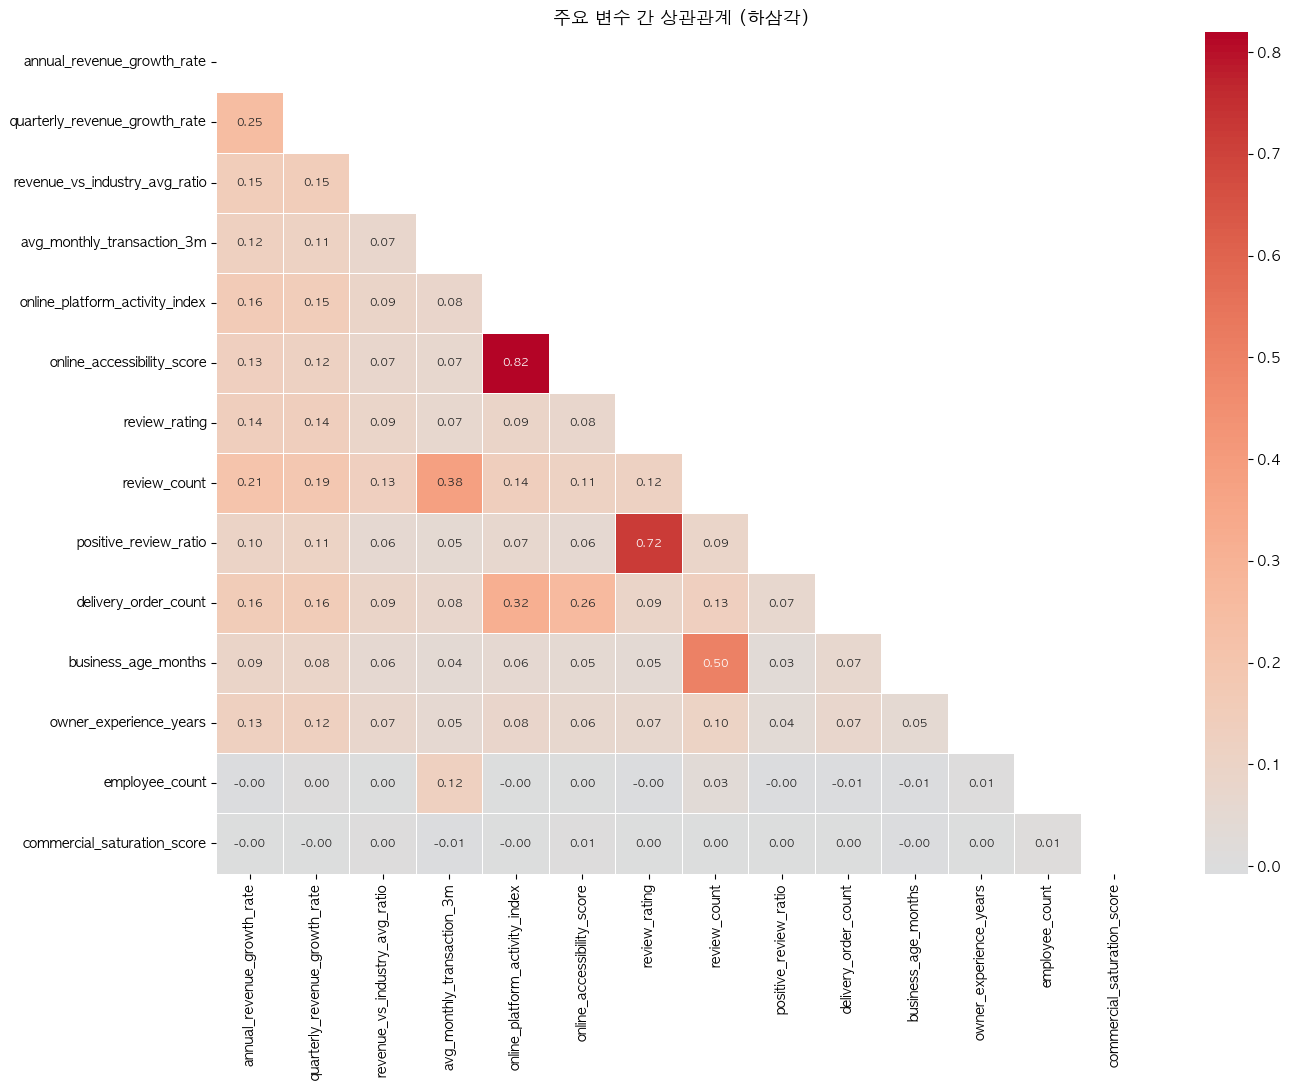

In [6]:
# 분석에 의미 있는 수치형 컬럼만 선택
key_cols = [
    'annual_revenue_growth_rate', 'quarterly_revenue_growth_rate',
    'revenue_vs_industry_avg_ratio', 'avg_monthly_transaction_3m',
    'online_platform_activity_index', 'online_accessibility_score',
    'review_rating', 'review_count', 'positive_review_ratio',
    'delivery_order_count', 'business_age_months',
    'owner_experience_years', 'employee_count',
    'commercial_saturation_score',
]

plt.figure(figsize=(14, 11))
corr = df[key_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))  # 상삼각 마스크
sns.heatmap(corr, mask=mask, cmap='coolwarm', center=0,
            annot=True, fmt='.2f', annot_kws={'size': 8},
            linewidths=0.5)
plt.title('주요 변수 간 상관관계 (하삼각)', fontsize=13)
plt.tight_layout()
plt.show()

## 6. 비선형 시나리오 검증

설계한 비선형 상호작용 항이 실제로 등급에 영향을 주는지 확인합니다.